In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data.csv", sep=";")
df.head(5)

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-01-01,2451300,15,31,1,30.3,0.0,56.780112,60.699355,0,2,620000.0,NaN,66,1632918.0
1,2021-01-01,1450000,5,5,1,33.0,6.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
2,2021-01-01,10700000,4,13,3,85.0,12.0,55.540060,37.725112,3,0,142701.0,242543.0,50,681306.0
3,2021-01-01,3100000,3,5,3,82.0,9.0,44.608154,40.138381,0,0,385000.0,NaN,1,NaN
4,2021-01-01,2500000,2,3,1,30.0,9.0,44.738685,37.713668,3,2,353960.0,439378.0,23,1730985.0


In [4]:
df.shape

(11358150, 15)

In [5]:
# Возьмем только Москву
df = df[df["id_region"] == 77]

In [6]:
df.shape

(1032600, 15)

In [7]:
# Удаляем ненужные колонки
df.drop(columns=["postal_code", "street_id", "house_id", "date", "id_region"], inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1032600 entries, 10 to 11358131
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   price          1032600 non-null  int64  
 1   level          1032600 non-null  int64  
 2   levels         1032600 non-null  int64  
 3   rooms          1032600 non-null  int64  
 4   area           1032600 non-null  float64
 5   kitchen_area   1032600 non-null  float64
 6   geo_lat        1032600 non-null  float64
 7   geo_lon        1032600 non-null  float64
 8   building_type  1032600 non-null  int64  
 9   object_type    1032600 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 86.7 MB


In [9]:
df.isna().sum()

price            0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
geo_lat          0
geo_lon          0
building_type    0
object_type      0
dtype: int64

## Обработка выбросов

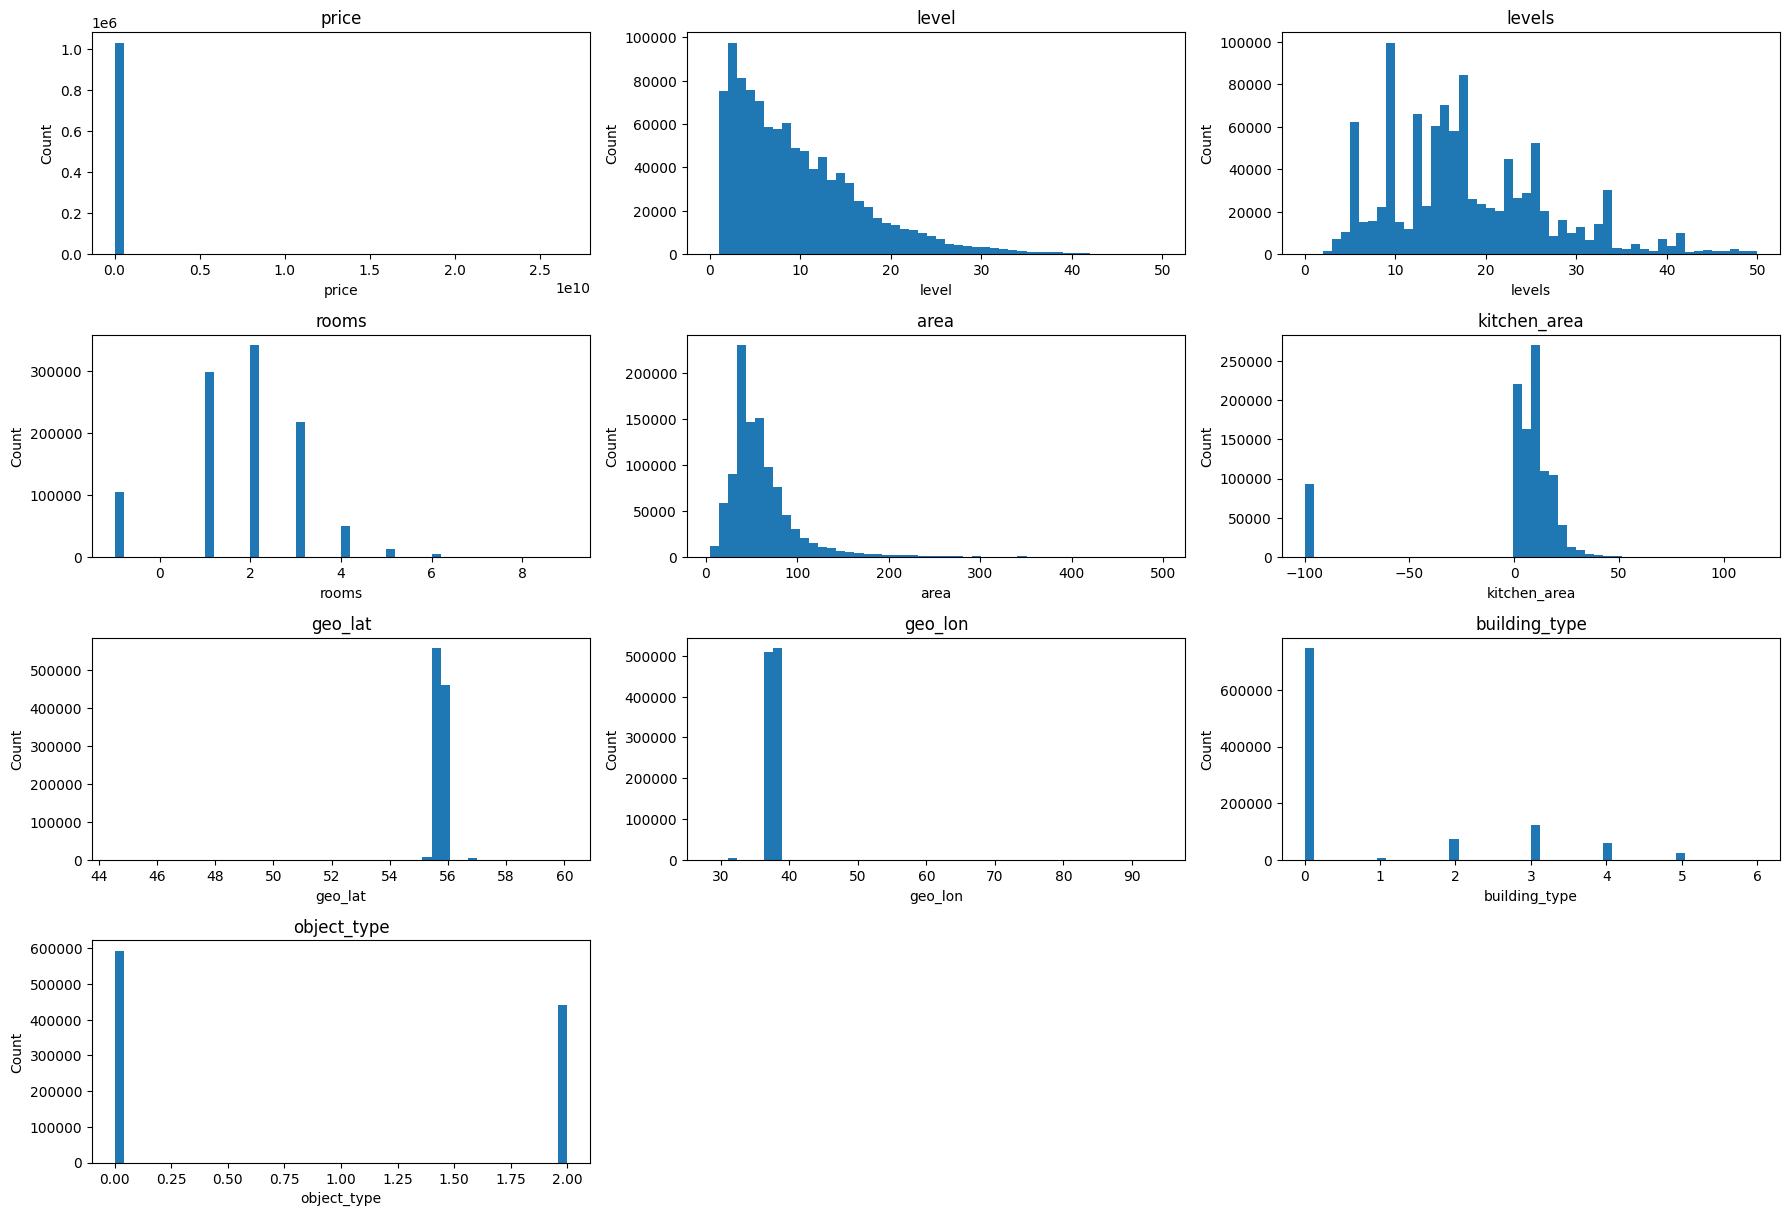

In [10]:
plt.figure(figsize=(18, 30))

for i, col in enumerate(df.columns):
    plt.subplot(10, 3, i + 1)
    plt.hist(df[col].dropna(), bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [11]:
q1 = df["price"].quantile(0.01)
q99 = df["price"].quantile(0.99)

df = df[
    (df["price"] >= q1) &
    (df["price"] <= q99)
]

In [12]:
q99 = df["area"].quantile(0.99)
df = df[df["area"] <= q99]

In [13]:
df[df["kitchen_area"] < 0].shape[0]

85897

In [14]:
# В площади кухни есть отрицательные значения, убираем эти строки
df = df[df["kitchen_area"] >= 0]

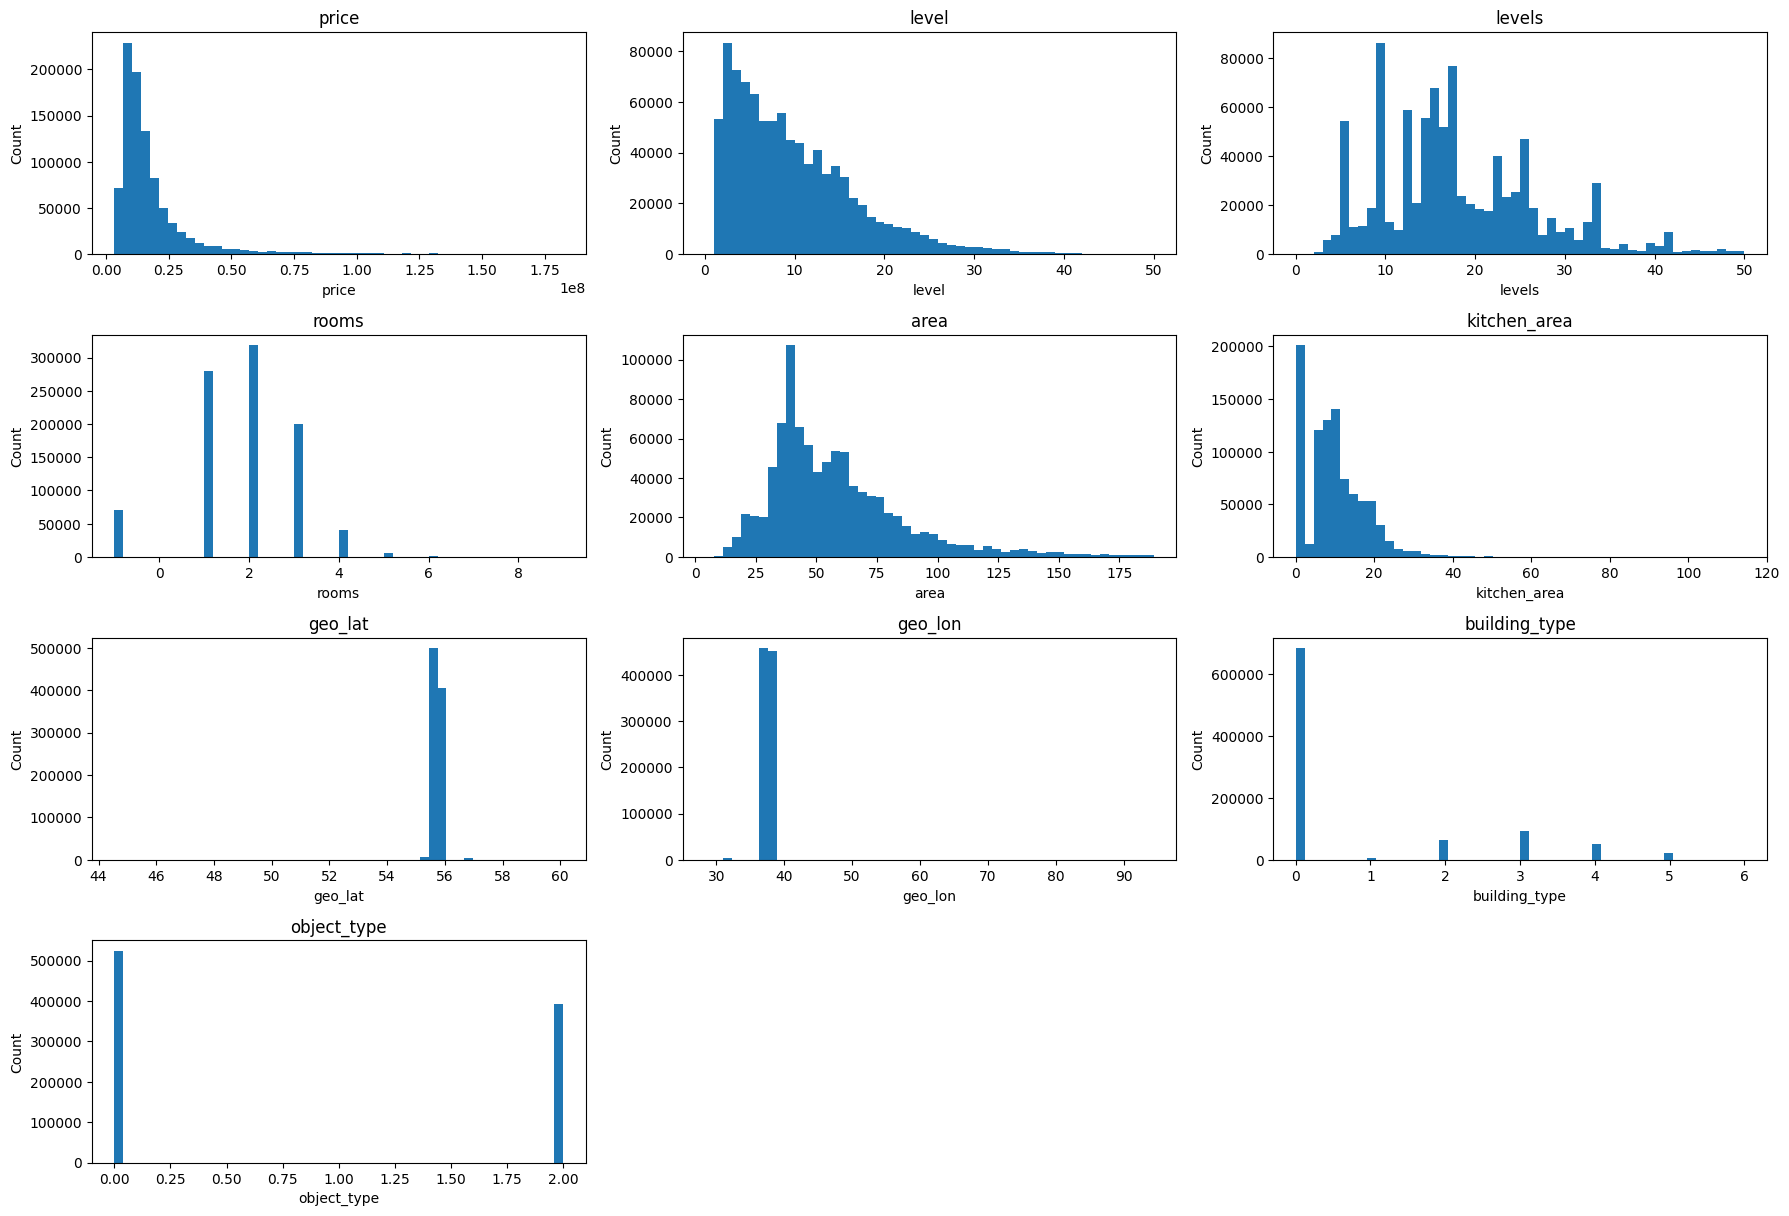

In [15]:
plt.figure(figsize=(18, 30))

for i, col in enumerate(df.columns):
    plt.subplot(10, 3, i + 1)
    plt.hist(df[col].dropna(), bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Обработка признаков и создание новых

In [16]:
df["rooms"].unique()

array([-1,  3,  1,  2,  4,  5,  8,  7,  6,  9])

-1 - студия = 0 комнат (меняем -1 на 0)

In [17]:
df["rooms"] = df["rooms"].replace(-1, 0)

In [18]:
df["rooms"].unique()

array([0, 3, 1, 2, 4, 5, 8, 7, 6, 9])

In [19]:
# Считаем жилую площадь (общая площаль - площадь кухни)
df["living_area"] = df["area"] - df["kitchen_area"]

In [20]:
# Считаем цену за квадратный метр - ее будем предсказывать
df["price_per_m2"] = df["price"] / df["area"]

In [21]:
# Считаем сколько комнат на один квадратный метр 
df["room_density"] = df["rooms"] / df["area"]

In [22]:
df["level"].unique(), df["levels"].unique()

(array([ 1, 11,  8,  9, 19, 17, 21,  4,  5, 14,  2,  6,  3, 12, 10,  7, 26,
        18, 22, 15, 13, 20, 25, 28, 24, 16, 23, 32, 31, 27, 34, 33, 29, 30,
        35, 40, 46, 45, 50, 37, 41, 38, 42, 36, 39, 43, 44, 47, 48,  0, 49]),
 array([19, 22, 29,  9, 31, 32, 18, 15, 16, 14, 12,  8, 17, 33,  5, 34, 25,
        23, 39, 11, 13, 24,  7,  6, 20, 28, 21, 27, 10, 41, 38,  4, 30, 36,
        26,  3, 47, 40, 44, 43, 46, 42, 35,  2, 45, 37, 48, 50,  1,  0, 49]))

In [23]:
# Удаляем строки где указан 0 этаж или в указано что в доме 0 этажей - такого быть не может
df.drop(df[df["level"] == 0].index, inplace=True)
df.drop(df[df["levels"] == 0].index, inplace=True)

In [24]:
# Сооттношение этажа квартиры и этажа дома
df["floor_ratio"] = df["level"] / df["levels"]

In [25]:
# Считаем расстояниие до центра по координатам
def distance_to_center(lat, lon):
    center_lat, center_lon = 55.751244, 37.618423
    return np.sqrt((lat - center_lat)**2 + (lon - center_lon)**2)

df["dist_to_center"] = distance_to_center(df["geo_lat"], df["geo_lon"])

In [26]:
# Разбиваем точки по координатам на 20 кластеров (условные районы)

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=20)
df["geo_cluster"] = kmeans.fit_predict(df[["geo_lat", "geo_lon"]])

Переводим building_type и object_type в бинарный признак

In [27]:
df["building_type"] = df["building_type"].astype("category")
df["object_type"] = df["object_type"].astype("category")

In [28]:
df = pd.get_dummies(
    df,
    columns=["building_type", "object_type"],
    drop_first=True
)

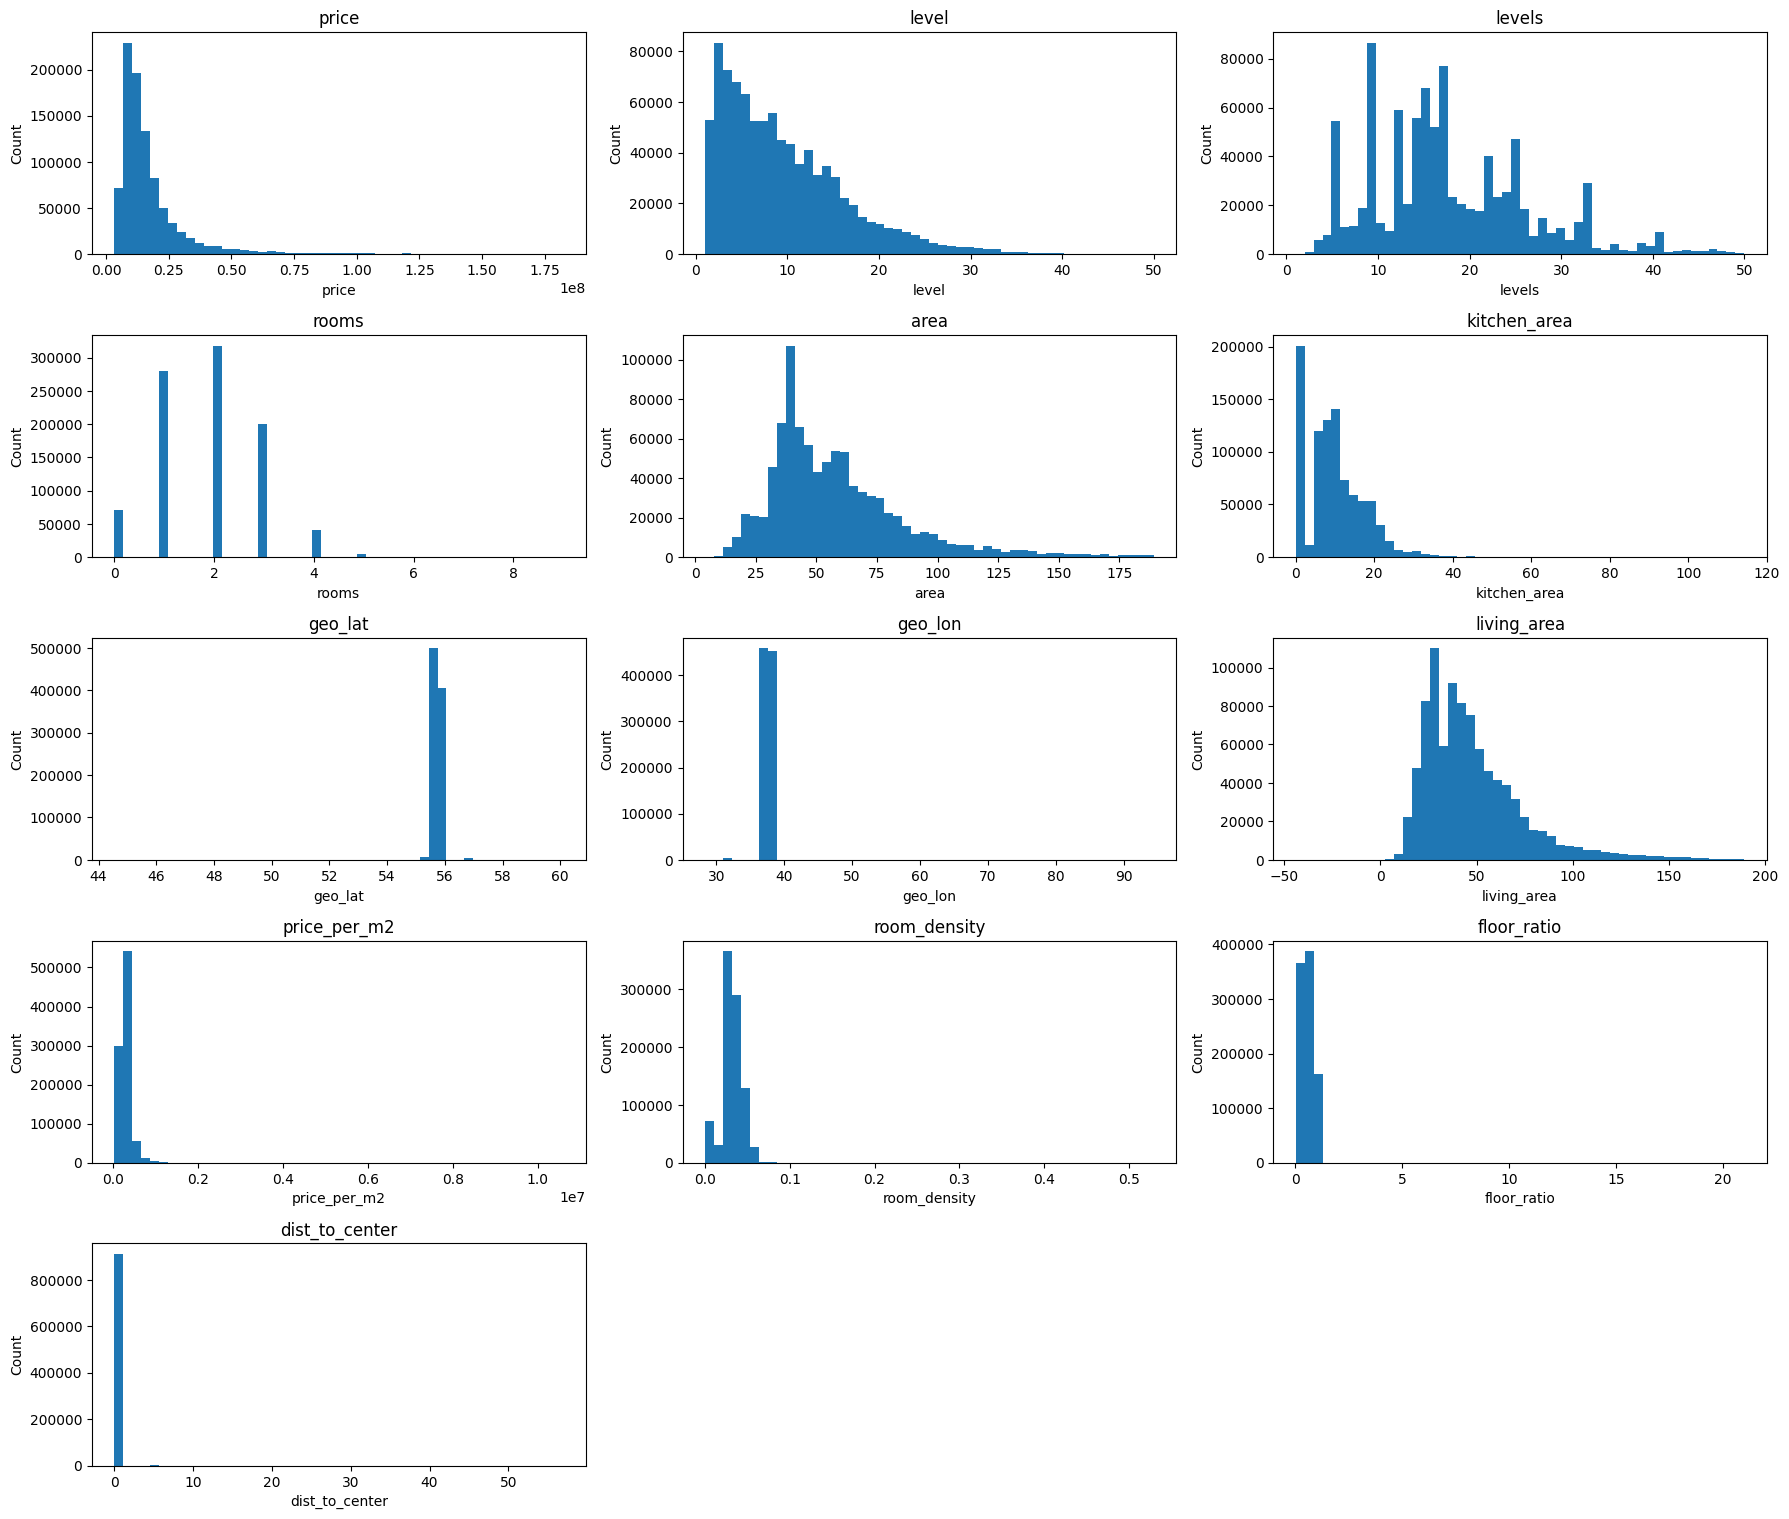

In [29]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 30))

for i, col in enumerate(numeric_cols):
    plt.subplot(10, 3, i + 1)
    plt.hist(df[col].dropna(), bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 915815 entries, 10 to 11358130
Data columns (total 21 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   price            915815 non-null  int64  
 1   level            915815 non-null  int64  
 2   levels           915815 non-null  int64  
 3   rooms            915815 non-null  int64  
 4   area             915815 non-null  float64
 5   kitchen_area     915815 non-null  float64
 6   geo_lat          915815 non-null  float64
 7   geo_lon          915815 non-null  float64
 8   living_area      915815 non-null  float64
 9   price_per_m2     915815 non-null  float64
 10  room_density     915815 non-null  float64
 11  floor_ratio      915815 non-null  float64
 12  dist_to_center   915815 non-null  float64
 13  geo_cluster      915815 non-null  int32  
 14  building_type_1  915815 non-null  bool   
 15  building_type_2  915815 non-null  bool   
 16  building_type_3  915815 non-null  bool  

In [31]:
df.isna().sum()

price              0
level              0
levels             0
rooms              0
area               0
kitchen_area       0
geo_lat            0
geo_lon            0
living_area        0
price_per_m2       0
room_density       0
floor_ratio        0
dist_to_center     0
geo_cluster        0
building_type_1    0
building_type_2    0
building_type_3    0
building_type_4    0
building_type_5    0
building_type_6    0
object_type_2      0
dtype: int64

In [32]:
df.to_csv("clean_data.csv", index=None)